# BD-KDD Dataset — Exploratory Data Analysis

## Objective

Perform a systematic, reproducible exploratory data analysis of the raw BD-KDD clinical dataset before any DODA-based feature selection or predictive modeling.

### Analysis goals

- Verify the structure and integrity of the raw dataset
- Audit missing values and hidden missing-value representations
- Check duplicate records and identifier behavior
- Characterize numerical and binary/ordinal variables
- Inspect the target distribution
- Examine distributions, ranges, and potential outliers
- Compare feature behavior across target classes
- Investigate correlations and potential redundancy
- Screen for possible data leakage
- Document data-quality decisions before cleaning
- Create and validate a separate processed dataset

**Important:** The raw dataset is never modified by this notebook. All cleaning is performed on a copy and the result is saved separately.


## 1. Imports

Only libraries required for EDA, visualization, and data-quality auditing are imported here.


In [35]:
# ============================================
# 1. IMPORT LIBRARIES
# ============================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

# Plotting settings
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Project Paths

The confirmed dataset location is used directly.

The raw CSV remains untouched. The cleaned dataset will be written to the existing `processed` directory.


In [36]:
# ============================================
# 2. PROJECT PATHS
# ============================================

# Confirmed project data location
DATA_ROOT = Path(r"C:\Users\johnm\msc_research\notebooks")

RAW_DIR = DATA_ROOT / "data" / "raw"
PROCESSED_DIR = DATA_ROOT / "data" / "processed"

DATA_PATH = RAW_DIR / "BD-KDD Dataset.csv"
PROCESSED_PATH = PROCESSED_DIR / "BD-KDD_cleaned.csv"

print("Raw data path       :", DATA_PATH)
print("Processed data path :", PROCESSED_PATH)
print("Raw file exists     :", DATA_PATH.exists())
print("Processed directory :", PROCESSED_DIR.exists())


Raw data path       : C:\Users\johnm\msc_research\notebooks\data\raw\BD-KDD Dataset.csv
Processed data path : C:\Users\johnm\msc_research\notebooks\data\processed\BD-KDD_cleaned.csv
Raw file exists     : True
Processed directory : True


## 3. Load Raw Dataset

The CSV is loaded exactly as provided. No values are changed at this stage.


In [37]:
# ============================================
# 3. LOAD RAW DATASET
# ============================================

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]:,}")


Dataset loaded successfully.
Rows    : 988
Columns : 26


## 4. Initial Dataset Inspection

First inspect the raw observations and schema before making any preprocessing decisions.


In [38]:
# ============================================
# 4.1 FIRST 5 ROWS
# ============================================

display(df.head())


,Sl. No.,Age,Bp,Sg,Al,Su,Rbc,Pc,Pcc,Ba,Bgr,Bu,Sc,Sod,Pot,Hemo,Pcv,Wbcc,Rbcc,Htn,Dm,Cad,Appet,Pe,Ane,Class
0,1,58,147,1.025,1,3,0,1,0,0,177,76,5.820,132,4.570,9.300,43,12342,4.300,1,0,0,1,1,0,0
1,2,71,142,1.025,2,3,1,0,1,0,247,149,9.480,141,4.640,16.900,47,7249,3.700,0,1,1,0,1,1,1
2,3,48,179,1.005,0,4,1,1,0,1,367,109,2.810,132,4.750,16.600,37,4111,3.700,0,0,0,0,0,1,0
3,4,34,70,1.005,1,3,1,1,0,0,215,21,14.540,140,5.140,15.400,44,4682,4.000,1,0,1,1,0,1,1
4,5,62,120,1.020,4,0,1,0,1,0,143,75,13.760,141,5.160,13.900,54,5161,4.700,0,0,1,0,1,0,1


In [39]:
# ============================================
# 4.2 LAST 5 ROWS
# ============================================

display(df.tail())


,Sl. No.,Age,Bp,Sg,Al,Su,Rbc,Pc,Pcc,Ba,Bgr,Bu,Sc,Sod,Pot,Hemo,Pcv,Wbcc,Rbcc,Htn,Dm,Cad,Appet,Pe,Ane,Class
983,984,29,157,1.015,0,3,1,0,0,0,164,83,8.720,148,6.250,15.900,29,14801,4.900,0,1,1,0,0,1,0
984,985,29,72,1.005,3,4,0,1,1,0,295,55,5.640,139,4.660,9.600,49,12313,5.600,0,0,1,0,1,1,1
985,986,38,101,1.020,1,2,1,1,0,1,75,78,6.030,144,5.190,16.300,39,10105,4.800,0,1,1,1,0,1,1
986,987,36,168,1.015,2,4,0,1,0,1,283,123,6.470,140,5.910,12.900,48,6560,5.800,1,0,0,0,0,0,0
987,988,40,171,1.010,3,2,1,0,0,0,275,156,11.050,144,4.780,15.000,48,7037,5.100,0,0,1,0,1,0,1


In [40]:
# ============================================
# 4.3 DATASET DIMENSIONS
# ============================================

print(f"Number of rows    : {df.shape[0]:,}")
print(f"Number of columns : {df.shape[1]:,}")


Number of rows    : 988
Number of columns : 26


In [41]:
# ============================================
# 4.4 COLUMN NAMES
# ============================================

for i, column in enumerate(df.columns, start=1):
    print(f"{i:02d}. {column}")


01. Sl. No.
02. Age
03. Bp
04. Sg
05. Al
06. Su
07. Rbc
08. Pc
09. Pcc
10. Ba
11. Bgr
12. Bu
13. Sc
14. Sod
15. Pot
16. Hemo
17. Pcv
18. Wbcc
19. Rbcc
20. Htn
21. Dm
22. Cad
23. Appet
24. Pe
25. Ane
26. Class


In [42]:
# ============================================
# 4.5 DATA TYPES
# ============================================

display(df.dtypes.to_frame(name="Data Type"))


,Data Type
Sl. No.,int64
Age,int64
Bp,int64
Sg,float64
Al,int64
Su,int64
Rbc,int64
Pc,int64
Pcc,int64
Ba,int64


In [43]:
# ============================================
# 4.6 DATASET INFORMATION
# ============================================

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 988 entries, 0 to 987
Data columns (total 26 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Sl. No.  988 non-null    int64  
 1   Age      988 non-null    int64  
 2   Bp       988 non-null    int64  
 3   Sg       988 non-null    float64
 4   Al       988 non-null    int64  
 5   Su       988 non-null    int64  
 6   Rbc      988 non-null    int64  
 7   Pc       988 non-null    int64  
 8   Pcc      988 non-null    int64  
 9   Ba       988 non-null    int64  
 10  Bgr      988 non-null    int64  
 11  Bu       988 non-null    int64  
 12  Sc       988 non-null    float64
 13  Sod      988 non-null    int64  
 14  Pot      988 non-null    float64
 15  Hemo     988 non-null    float64
 16  Pcv      988 non-null    int64  
 17  Wbcc     988 non-null    int64  
 18  Rbcc     988 non-null    float64
 19  Htn      988 non-null    int64  
 20  Dm       988 non-null    int64  
 21  Cad      988 non-null    in

## 5. Missing-Value Audit

Missingness is checked in several ways:

1. Pandas-recognized missing values
2. Hidden textual missing-value tokens
3. Row-level missingness

No imputation or deletion is performed during this section.


In [44]:
# ============================================
# 5.1 COLUMN-LEVEL MISSING VALUES
# ============================================

missing_count = df.isna().sum()
missing_percent = (missing_count / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percent
}).sort_values("Missing Count", ascending=False)

display(missing_summary)


,Missing Count,Missing Percentage
Sl. No.,0,0.000
Age,0,0.000
Bp,0,0.000
Sg,0,0.000
Al,0,0.000
Su,0,0.000
Rbc,0,0.000
Pc,0,0.000
Pcc,0,0.000
Ba,0,0.000


In [45]:
# ============================================
# 5.2 TOTAL MISSING VALUES
# ============================================

print("Total missing values:", int(df.isna().sum().sum()))


Total missing values: 0


In [46]:
# ============================================
# 5.3 HIDDEN MISSING-VALUE TOKENS
# ============================================

missing_tokens = [
    "?", "NA", "N/A", "na", "n/a",
    "Unknown", "unknown", "-", ""
]

hidden_missing = {}

for token in missing_tokens:
    count = (df.astype(str) == token).sum().sum()
    if count > 0:
        hidden_missing[token] = int(count)

if hidden_missing:
    for token, count in hidden_missing.items():
        print(f"{token!r}: {count} occurrence(s)")
else:
    print("No predefined hidden missing-value tokens detected.")


No predefined hidden missing-value tokens detected.


In [47]:
# ============================================
# 5.4 ROW-LEVEL MISSINGNESS
# ============================================

missing_by_row = df.isna().sum(axis=1)

print("Rows containing missing values :", int((missing_by_row > 0).sum()))
print("Maximum missing values in row :", int(missing_by_row.max()))


Rows containing missing values : 0
Maximum missing values in row : 0


## 6. Duplicate and Identifier Audit

Exact duplicate rows and identifier behavior are assessed separately.

`Sl. No.` is treated as a potential identifier, not as a clinical predictor, until its behavior is verified.


In [48]:
# ============================================
# 6.1 EXACT DUPLICATE ROWS
# ============================================

duplicate_count = int(df.duplicated().sum())

print("Exact duplicate rows :", duplicate_count)
print(f"Duplicate percentage : {duplicate_count / len(df) * 100:.2f}%")


Exact duplicate rows : 0
Duplicate percentage : 0.00%


In [49]:
# ============================================
# 6.2 IDENTIFIER AUDIT
# ============================================

id_col = "Sl. No."

print("Unique IDs :", df[id_col].nunique())
print("Total rows :", len(df))
print("Duplicate IDs :", int(df[id_col].duplicated().sum()))

print("\nFirst 10 IDs:")
display(df[id_col].head(10).to_frame())


Unique IDs : 988
Total rows : 988
Duplicate IDs : 0

First 10 IDs:


,Sl. No.
0,1
1,2
2,3
3,4
4,5
5,6
6,7
7,8
8,9
9,10


In [50]:
# ============================================
# 6.3 ID SEQUENCE CHECK
# ============================================

expected_ids = np.arange(1, len(df) + 1)

print("IDs are exactly 1..N:",
      bool(np.array_equal(df[id_col].to_numpy(), expected_ids)))


IDs are exactly 1..N: True


## 7. Variable Inventory

The dataset contains numerical measurements as well as binary/ordinal encoded clinical variables.

The table below documents the analytical role of each variable without changing the raw column names.


In [51]:
# ============================================
# 7. VARIABLE INVENTORY
# ============================================

variable_inventory = pd.DataFrame([
    ["Sl. No.", "Identifier", "Administrative", "Exclude from modeling"],
    ["Age", "Numerical", "Demographic", "Predictor"],
    ["Bp", "Numerical", "Vital sign", "Predictor"],
    ["Sg", "Ordinal", "Urinalysis", "Predictor"],
    ["Al", "Ordinal", "Urinalysis", "Predictor"],
    ["Su", "Ordinal", "Urinalysis", "Predictor"],
    ["Rbc", "Binary encoded", "Urinalysis", "Predictor"],
    ["Pc", "Binary encoded", "Urinalysis", "Predictor"],
    ["Pcc", "Binary encoded", "Urinalysis", "Predictor"],
    ["Ba", "Binary encoded", "Urinalysis", "Predictor"],
    ["Bgr", "Numerical", "Blood laboratory", "Predictor"],
    ["Bu", "Numerical", "Renal laboratory", "Predictor"],
    ["Sc", "Numerical", "Renal laboratory", "Predictor"],
    ["Sod", "Numerical", "Electrolyte", "Predictor"],
    ["Pot", "Numerical", "Electrolyte", "Predictor"],
    ["Hemo", "Numerical", "Hematology", "Predictor"],
    ["Pcv", "Numerical", "Hematology", "Predictor"],
    ["Wbcc", "Numerical", "Hematology", "Predictor"],
    ["Rbcc", "Numerical", "Hematology", "Predictor"],
    ["Htn", "Binary encoded", "Comorbidity", "Predictor"],
    ["Dm", "Binary encoded", "Comorbidity", "Predictor"],
    ["Cad", "Binary encoded", "Comorbidity", "Predictor"],
    ["Appet", "Binary encoded", "Clinical symptom", "Predictor"],
    ["Pe", "Binary encoded", "Clinical symptom", "Predictor"],
    ["Ane", "Binary encoded", "Clinical symptom", "Predictor"],
    ["Class", "Binary target", "Outcome", "Target"],
], columns=["Feature", "Variable Type", "Clinical Group", "Modeling Role"])

display(variable_inventory)


,Feature,Variable Type,Clinical Group,Modeling Role
0,Sl. No.,Identifier,Administrative,Exclude from modeling
1,Age,Numerical,Demographic,Predictor
2,Bp,Numerical,Vital sign,Predictor
3,Sg,Ordinal,Urinalysis,Predictor
4,Al,Ordinal,Urinalysis,Predictor
5,Su,Ordinal,Urinalysis,Predictor
6,Rbc,Binary encoded,Urinalysis,Predictor
7,Pc,Binary encoded,Urinalysis,Predictor
8,Pcc,Binary encoded,Urinalysis,Predictor
9,Ba,Binary encoded,Urinalysis,Predictor


## 8. Unique-Value and Encoding Audit

This section verifies how variables are actually encoded in the CSV.

Binary variables should contain only two distinct values, while ordinal variables such as `Sg`, `Al`, and `Su` should be inspected for their observed levels.


In [52]:
# ============================================
# 8.1 UNIQUE VALUE COUNTS
# ============================================

unique_summary = pd.DataFrame({
    "Unique Values": df.nunique(dropna=False),
    "Data Type": df.dtypes.astype(str)
})

display(unique_summary)


,Unique Values,Data Type
Sl. No.,988,int64
Age,60,int64
Bp,110,int64
Sg,5,float64
Al,5,int64
Su,5,int64
Rbc,2,int64
Pc,2,int64
Pcc,2,int64
Ba,2,int64


In [53]:
# ============================================
# 8.2 VALUES OF LOW-CARDINALITY VARIABLES
# ============================================

low_cardinality_cols = [
    "Sg", "Al", "Su",
    "Rbc", "Pc", "Pcc", "Ba",
    "Htn", "Dm", "Cad",
    "Appet", "Pe", "Ane",
    "Class"
]

for col in low_cardinality_cols:
    print(f"{col}: {sorted(df[col].unique().tolist())}")


Sg: [1.005, 1.01, 1.015, 1.02, 1.025]
Al: [0, 1, 2, 3, 4]
Su: [0, 1, 2, 3, 4]
Rbc: [0, 1]
Pc: [0, 1]
Pcc: [0, 1]
Ba: [0, 1]
Htn: [0, 1]
Dm: [0, 1]
Cad: [0, 1]
Appet: [0, 1]
Pe: [0, 1]
Ane: [0, 1]
Class: [0, 1]


In [54]:
# ============================================
# 8.3 BINARY VARIABLE VALIDATION
# ============================================

binary_cols = [
    "Rbc", "Pc", "Pcc", "Ba",
    "Htn", "Dm", "Cad",
    "Appet", "Pe", "Ane"
]

binary_check = pd.DataFrame({
    "Unique Values": [df[col].nunique() for col in binary_cols],
    "Observed Values": [sorted(df[col].unique().tolist()) for col in binary_cols]
}, index=binary_cols)

display(binary_check)


,Unique Values,Observed Values
Rbc,2,"[0, 1]"
Pc,2,"[0, 1]"
Pcc,2,"[0, 1]"
Ba,2,"[0, 1]"
Htn,2,"[0, 1]"
Dm,2,"[0, 1]"
Cad,2,"[0, 1]"
Appet,2,"[0, 1]"
Pe,2,"[0, 1]"
Ane,2,"[0, 1]"


## 9. Target Analysis

`Class` is inspected as the outcome variable.

The labels are kept as encoded in the dataset. Their clinical meaning will be reported according to the dataset documentation rather than inferred from the numeric values alone.


In [55]:
# ============================================
# 9.1 TARGET COUNTS
# ============================================

target_counts = df["Class"].value_counts(dropna=False).sort_index()

display(target_counts.to_frame(name="Count"))


,Count
Class,
0,481
1,507


In [56]:
# ============================================
# 9.2 TARGET DISTRIBUTION
# ============================================

target_distribution = pd.DataFrame({
    "Count": df["Class"].value_counts(dropna=False).sort_index(),
    "Percentage": (
        df["Class"]
        .value_counts(normalize=True, dropna=False)
        .sort_index() * 100
    )
})

display(target_distribution)


,Count,Percentage
Class,,
0,481,48.684
1,507,51.316


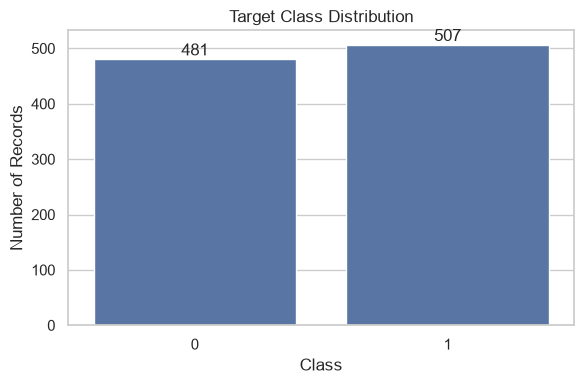

In [57]:
# ============================================
# 9.3 TARGET PLOT
# ============================================

plt.figure(figsize=(6, 4))

ax = sns.countplot(data=df, x="Class")

for container in ax.containers:
    ax.bar_label(container, fmt="%d")

plt.title("Target Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()


## 10. Numerical Feature Analysis

Descriptive statistics are calculated for numerical predictors.

This is an inspection stage only. No scaling, normalization, or outlier removal is performed here.


In [58]:
# ============================================
# 10.1 NUMERICAL FEATURES
# ============================================

numerical_cols = [
    "Age", "Bp", "Bgr", "Bu", "Sc",
    "Sod", "Pot", "Hemo", "Pcv",
    "Wbcc", "Rbcc"
]

display(df[numerical_cols].describe().T)


,count,mean,std,min,25%,50%,75%,max
Age,988.000,50.270,17.336,20.000,36.000,51.000,66.000,79.000
Bp,988.000,123.756,32.193,70.000,95.000,123.000,153.000,179.000
Bgr,988.000,232.094,97.014,70.000,147.750,233.000,316.000,399.000
Bu,988.000,104.243,52.957,10.000,58.000,106.500,148.000,199.000
Sc,988.000,7.536,4.142,0.500,3.978,7.520,10.930,14.980
Sod,988.000,139.721,5.717,130.000,135.000,140.000,145.000,149.000
Pot,988.000,4.970,0.853,3.510,4.250,4.990,5.680,6.500
Hemo,988.000,12.078,2.858,7.000,9.775,12.100,14.500,17.000
Pcv,988.000,36.722,9.879,20.000,28.000,37.000,45.000,54.000
Wbcc,988.000,9579.932,3156.570,4012.000,6943.000,9612.000,12291.000,14987.000


In [59]:
# ============================================
# 10.2 RANGE SUMMARY
# ============================================

range_summary = pd.DataFrame({
    "Minimum": df[numerical_cols].min(),
    "Maximum": df[numerical_cols].max(),
    "Range": df[numerical_cols].max() - df[numerical_cols].min(),
    "Unique Values": df[numerical_cols].nunique()
})

display(range_summary)


,Minimum,Maximum,Range,Unique Values
Age,20.000,79.000,59.000,60
Bp,70.000,179.000,109.000,110
Bgr,70.000,399.000,329.000,313
Bu,10.000,199.000,189.000,188
Sc,0.500,14.980,14.480,725
Sod,130.000,149.000,19.000,20
Pot,3.510,6.500,2.990,288
Hemo,7.000,17.000,10.000,101
Pcv,20.000,54.000,34.000,35
Wbcc,4012.000,14987.000,10975.000,948


In [60]:
# ============================================
# 10.3 ZERO AND NEGATIVE VALUE CHECK
# ============================================

zero_counts = (df[numerical_cols] == 0).sum()
negative_counts = (df[numerical_cols] < 0).sum()

range_flags = pd.DataFrame({
    "Zero Count": zero_counts,
    "Negative Count": negative_counts
})

display(range_flags)


,Zero Count,Negative Count
Age,0,0
Bp,0,0
Bgr,0,0
Bu,0,0
Sc,0,0
Sod,0,0
Pot,0,0
Hemo,0,0
Pcv,0,0
Wbcc,0,0


## 11. Numerical Distributions

Histograms are used to inspect the shape and spread of continuous/numerical variables.

These plots are exploratory and are not used by themselves to declare values invalid.


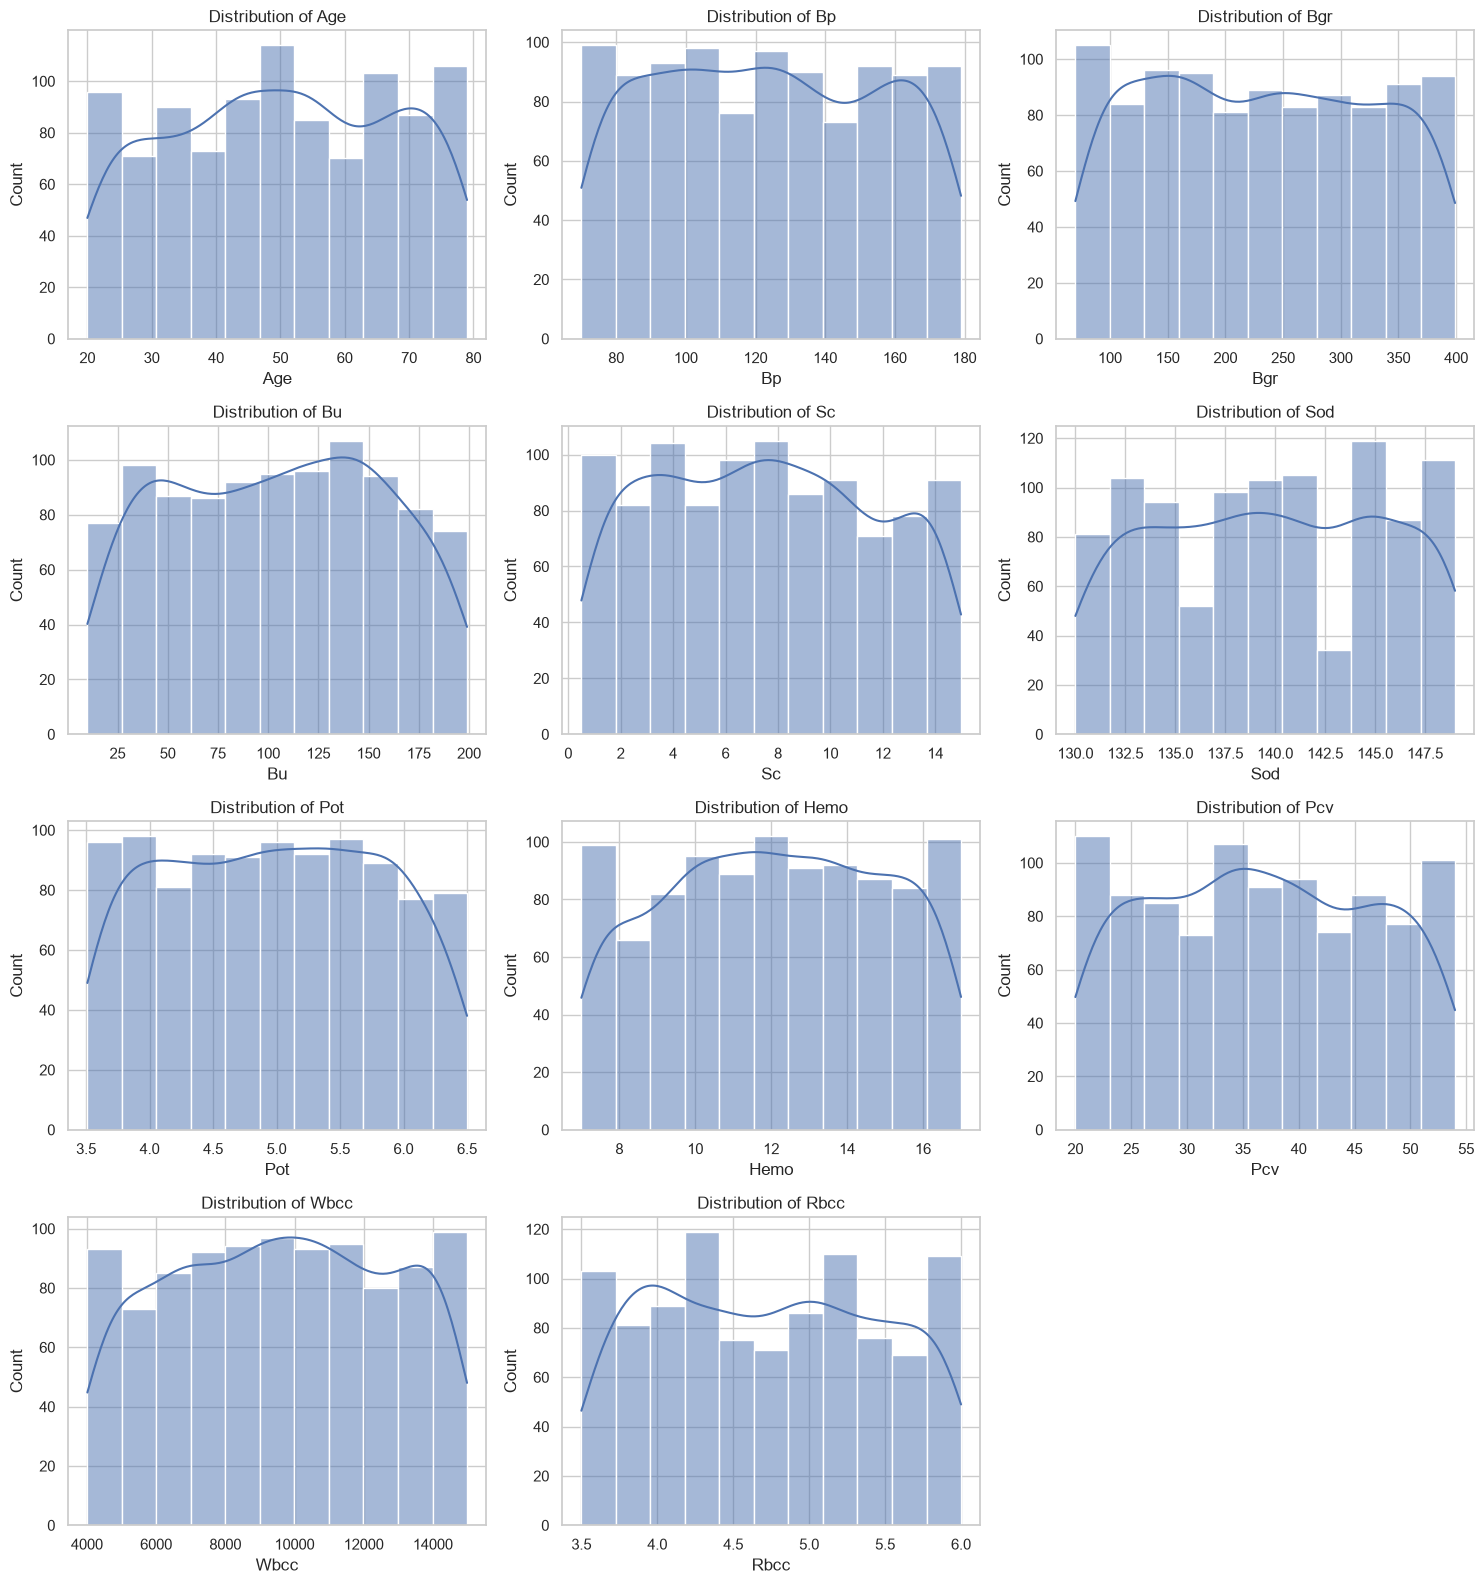

In [61]:
# ============================================
# 11.1 NUMERICAL DISTRIBUTIONS
# ============================================

n_cols = 3
n_rows = int(np.ceil(len(numerical_cols) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(15, 4 * n_rows)
)

axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, numerical_cols):
    sns.histplot(data=df, x=col, kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

for ax in axes[len(numerical_cols):]:
    ax.remove()

plt.tight_layout()
plt.show()


## 12. Categorical / Binary Feature Analysis

Frequency tables are generated for the binary and ordinal variables.

This allows us to verify class representation and detect unexpected encodings.


In [62]:
# ============================================
# 12.1 FREQUENCY TABLES
# ============================================

categorical_cols = [
    "Sg", "Al", "Su",
    "Rbc", "Pc", "Pcc", "Ba",
    "Htn", "Dm", "Cad",
    "Appet", "Pe", "Ane"
]

for col in categorical_cols:
    print(f"\n{'=' * 60}")
    print(f"{col}")
    print(f"{'=' * 60}")

    counts = df[col].value_counts(dropna=False).sort_index()
    percentages = (
        df[col].value_counts(normalize=True, dropna=False)
        .sort_index() * 100
    )

    summary = pd.DataFrame({
        "Count": counts,
        "Percentage": percentages
    })

    display(summary)



Sg


,Count,Percentage
Sg,,
1.005,189,19.130
1.010,204,20.648
1.015,172,17.409
1.020,212,21.457
1.025,211,21.356



Al


,Count,Percentage
Al,,
0,203,20.547
1,172,17.409
2,203,20.547
3,212,21.457
4,198,20.040



Su


...

,Count,Percentage
Appet,,
0,490,49.595
1,498,50.405



Pe


,Count,Percentage
Pe,,
0,508,51.417
1,480,48.583



Ane


,Count,Percentage
Ane,,
0,476,48.178
1,512,51.822


## 13. Clinical Plausibility Screening

This section flags observations that deserve inspection based on simple numerical rules.

**Important:** A statistical extreme is not automatically a clinical error. These checks identify records for review; they do not automatically delete or correct observations.

Clinical interpretation should be based on the dataset's documentation and appropriate clinical references.


In [63]:
# ============================================
# 13.1 SIMPLE PLAUSIBILITY FLAGS
# ============================================

plausibility_rules = {
    "Age": lambda s: s < 0,
    "Bp": lambda s: s <= 0,
    "Sg": lambda s: (s <= 0),
    "Bgr": lambda s: s < 0,
    "Bu": lambda s: s < 0,
    "Sc": lambda s: s < 0,
    "Sod": lambda s: s <= 0,
    "Pot": lambda s: s <= 0,
    "Hemo": lambda s: s <= 0,
    "Pcv": lambda s: s <= 0,
    "Wbcc": lambda s: s <= 0,
    "Rbcc": lambda s: s <= 0,
}

plausibility_summary = []

for col, rule in plausibility_rules.items():
    mask = rule(df[col])
    plausibility_summary.append({
        "Feature": col,
        "Flagged Records": int(mask.sum()),
        "Flag Percentage": float(mask.mean() * 100)
    })

plausibility_summary = pd.DataFrame(plausibility_summary)

display(plausibility_summary)


,Feature,Flagged Records,Flag Percentage
0,Age,0,0.000
1,Bp,0,0.000
2,Sg,0,0.000
3,Bgr,0,0.000
4,Bu,0,0.000
5,Sc,0,0.000
6,Sod,0,0.000
7,Pot,0,0.000
8,Hemo,0,0.000
9,Pcv,0,0.000


In [64]:
# ============================================
# 13.2 OBSERVED LEVELS FOR ORDINAL VARIABLES
# ============================================

ordinal_cols = ["Sg", "Al", "Su"]

ordinal_levels = pd.DataFrame({
    col: pd.Series(sorted(df[col].unique()))
    for col in ordinal_cols
})

display(ordinal_levels)


,Sg,Al,Su
0,1.005,0,0
1,1.010,1,1
2,1.015,2,2
3,1.020,3,3
4,1.025,4,4


## 14. Outlier Screening

The IQR rule is used only as a statistical screening method.

Outliers will **not** be removed automatically because clinically severe patients can legitimately produce extreme measurements.


In [65]:
# ============================================
# 14.1 IQR OUTLIER SUMMARY
# ============================================

outlier_rows = []

for col in numerical_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    mask = (df[col] < lower) | (df[col] > upper)

    outlier_rows.append({
        "Feature": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower Bound": lower,
        "Upper Bound": upper,
        "Outlier Count": int(mask.sum()),
        "Outlier Percentage": float(mask.mean() * 100)
    })

outlier_summary = pd.DataFrame(outlier_rows)

display(outlier_summary)


,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
0,Age,36.000,66.000,30.000,-9.000,111.000,0,0.000
1,Bp,95.000,153.000,58.000,8.000,240.000,0,0.000
2,Bgr,147.750,316.000,168.250,-104.625,568.375,0,0.000
3,Bu,58.000,148.000,90.000,-77.000,283.000,0,0.000
4,Sc,3.978,10.930,6.952,-6.451,21.359,0,0.000
5,Sod,135.000,145.000,10.000,120.000,160.000,0,0.000
6,Pot,4.250,5.680,1.430,2.105,7.825,0,0.000
7,Hemo,9.775,14.500,4.725,2.688,21.587,0,0.000
8,Pcv,28.000,45.000,17.000,2.500,70.500,0,0.000
9,Wbcc,6943.000,12291.000,5348.000,-1079.000,20313.000,0,0.000


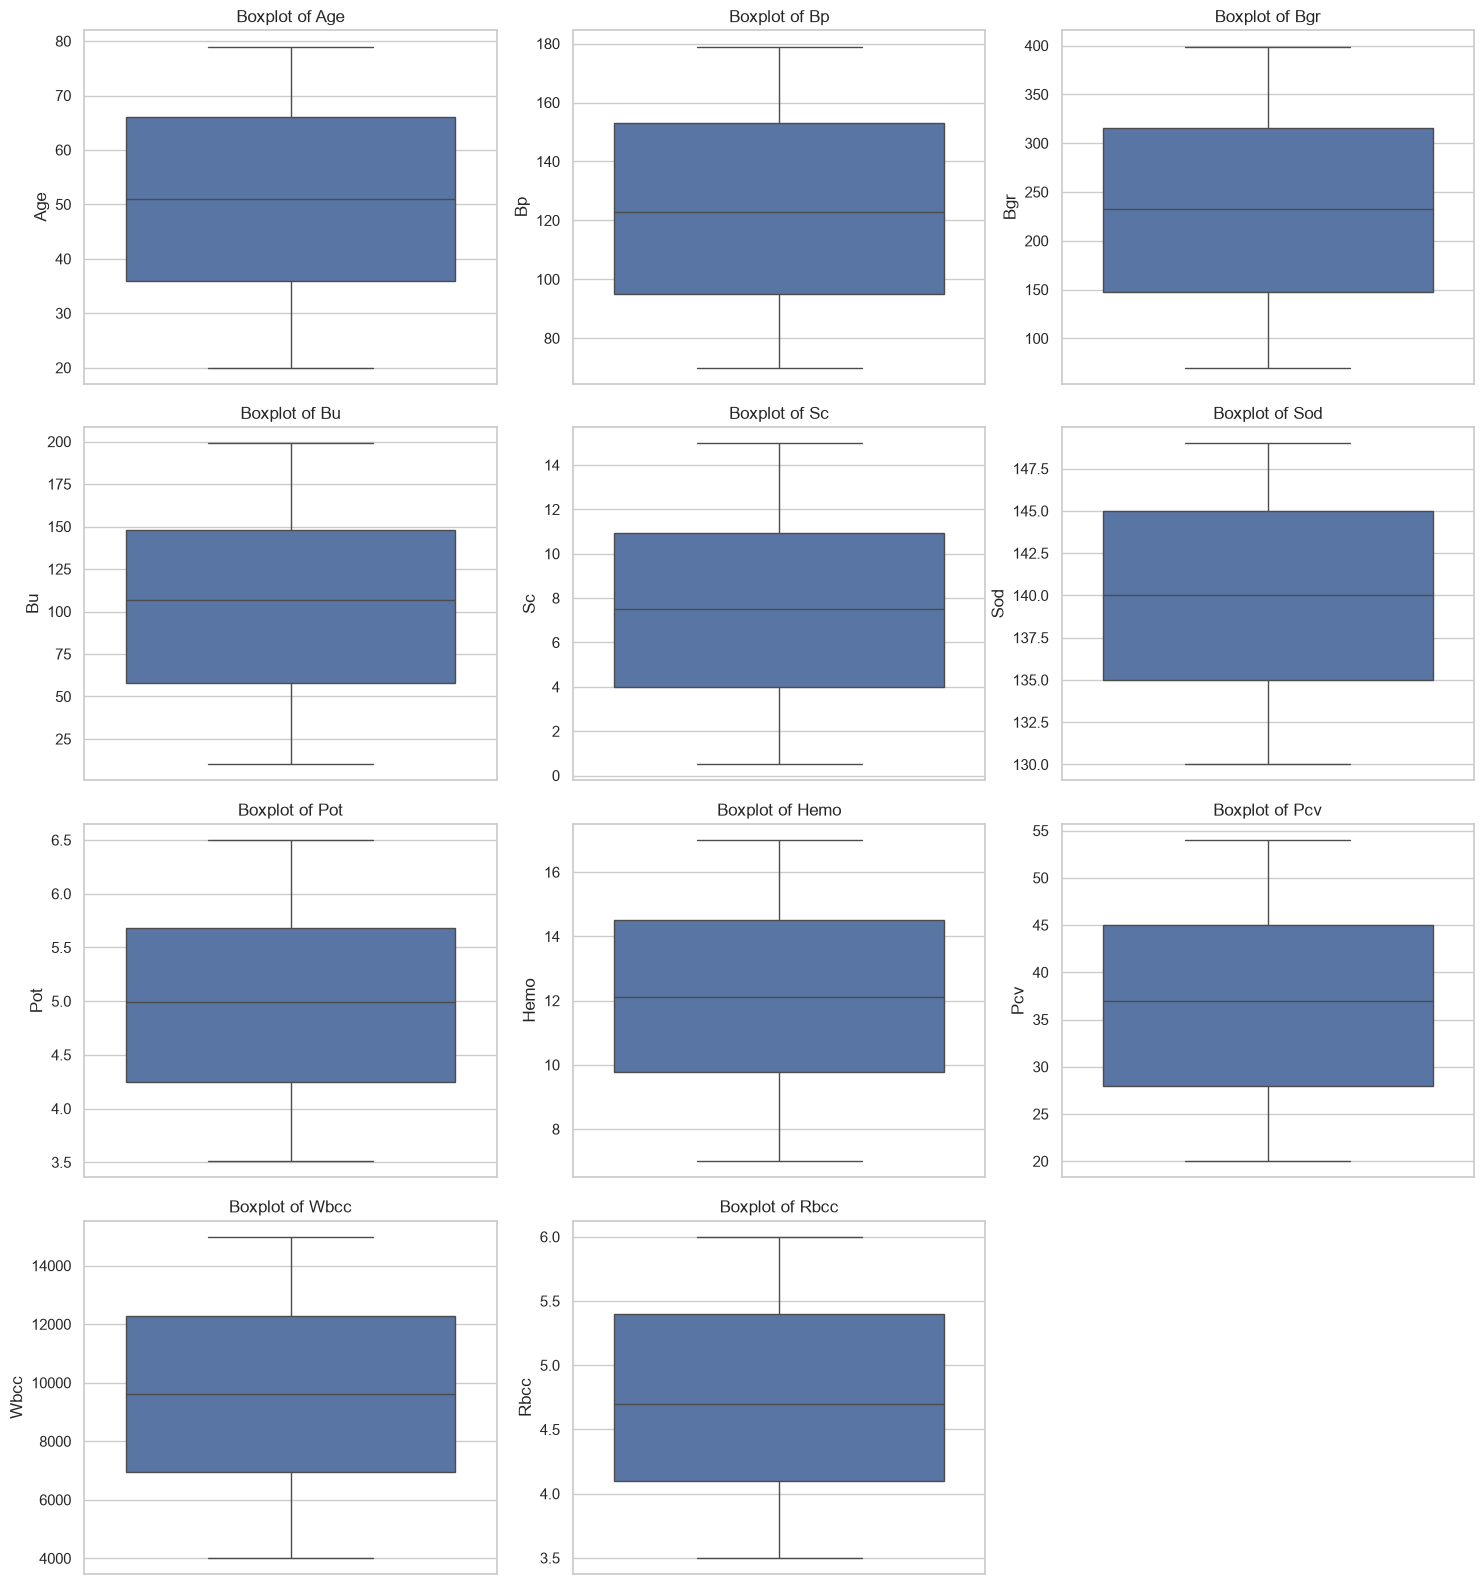

In [66]:
# ============================================
# 14.2 BOXPLOTS
# ============================================

n_cols = 3
n_rows = int(np.ceil(len(numerical_cols) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(15, 4 * n_rows)
)

axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, numerical_cols):
    sns.boxplot(data=df, y=col, ax=ax)
    ax.set_title(f"Boxplot of {col}")

for ax in axes[len(numerical_cols):]:
    ax.remove()

plt.tight_layout()
plt.show()


## 15. Class-Wise Feature Analysis

Feature distributions are compared between the two target classes.

This is descriptive analysis only. These comparisons are not used as a substitute for formal statistical testing or feature selection.


In [67]:
# ============================================
# 15.1 CLASS-WISE NUMERICAL SUMMARY
# ============================================

classwise_summary = (
    df.groupby("Class")[numerical_cols]
    .agg(["mean", "median", "std"])
)

display(classwise_summary)


Age                    Bp                    Bgr                 \
        mean median    std    mean  median    std    mean  median    std   
Class                                                                      
0     50.380 50.000 17.109 127.040 128.000 32.185 229.320 229.000 98.434   
1     50.166 51.000 17.565 120.641 119.000 31.920 234.726 235.000 95.669   

           Bu                   Sc                  Sod                 Pot  \
         mean  median    std  mean median   std    mean  median   std  mean   
Class                                                                         
0     102.524 102.000 54.772 7.411  7.100 4.174 139.578 139.000 5.678 4.935   
1     105.874 110.000 51.176 7.653  7.710 4.112 139.856 140.000 5.757 5.003   

                     Hemo                 Pcv                  Wbcc           \
      median   std   mean median   std   mean median   std     mean   median   
Class                                                                          
0      4.940 0.873 12.105 12.100 2.949 37.225 37.000 9.782 9616.690 9524.000   
1      5.020 0.833 12.053 12.100 2.771 36.245 36.000 9.956 9545.059 9668.000   

                Rbcc               
           std  mean median   std  
Class                              
0     3170.003 4.699  4.600 0.745  
1     3146.507 4.768  4.800 0.724

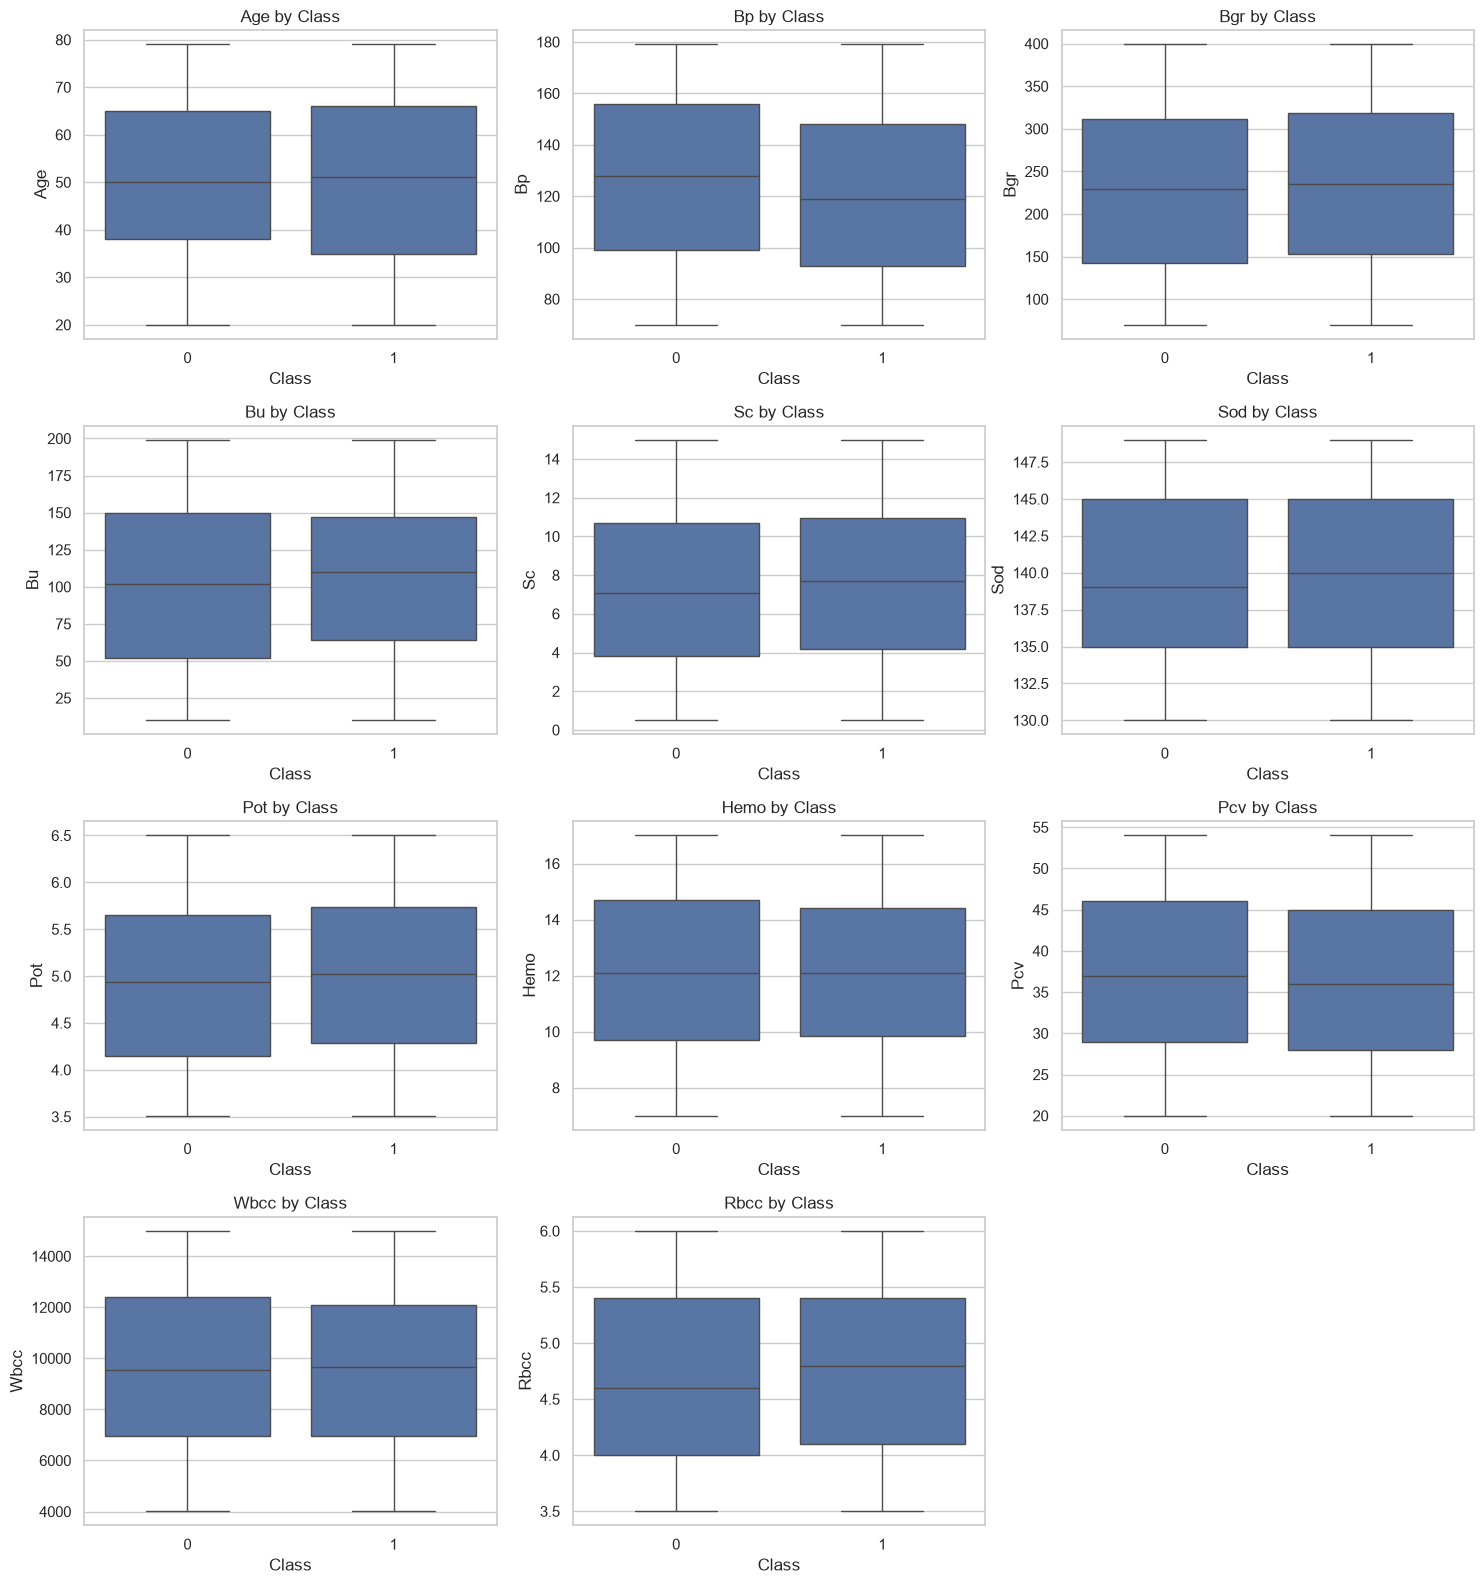

In [68]:
# ============================================
# 15.2 CLASS-WISE NUMERICAL BOXPLOTS
# ============================================

n_cols = 3
n_rows = int(np.ceil(len(numerical_cols) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(15, 4 * n_rows)
)

axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, numerical_cols):
    sns.boxplot(data=df, x="Class", y=col, ax=ax)
    ax.set_title(f"{col} by Class")

for ax in axes[len(numerical_cols):]:
    ax.remove()

plt.tight_layout()
plt.show()


In [69]:
# ============================================
# 15.3 BINARY FEATURE BY TARGET
# ============================================

binary_cols = [
    "Rbc", "Pc", "Pcc", "Ba",
    "Htn", "Dm", "Cad",
    "Appet", "Pe", "Ane"
]

for col in binary_cols:
    table = pd.crosstab(
        df[col],
        df["Class"],
        normalize="columns"
    ) * 100

    print(f"\n{col} (% within target class)")
    display(table)



Rbc (% within target class)


Class,0,1
Rbc,,
0,48.441,48.521
1,51.559,51.479



Pc (% within target class)


Class,0,1
Pc,,
0,48.649,49.112
1,51.351,50.888



Pcc (% within target class)


...

Class,0,1
Appet,,
0,48.025,51.085
1,51.975,48.915



Pe (% within target class)


Class,0,1
Pe,,
0,53.015,49.901
1,46.985,50.099



Ane (% within target class)


Class,0,1
Ane,,
0,49.688,46.746
1,50.312,53.254


## 16. Correlation and Feature Redundancy

Pearson correlation is used as an exploratory measure among numerical variables.

Correlation does not establish causation and does not determine whether a feature should be retained. It is used here to identify potentially redundant measurements that may affect feature-selection behavior.


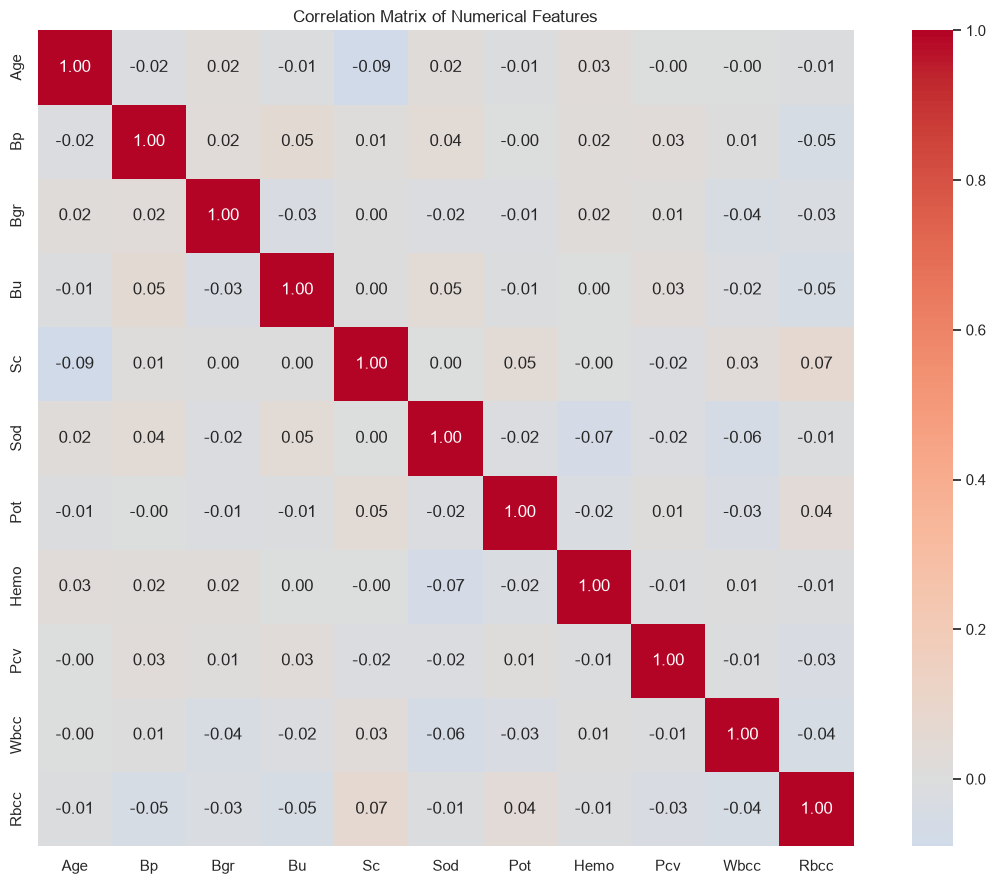

In [70]:
# ============================================
# 16.1 NUMERICAL CORRELATION MATRIX
# ============================================

correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()


In [71]:
# ============================================
# 16.2 HIGH-CORRELATION PAIRS
# ============================================

corr_pairs = (
    correlation_matrix
    .where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
    .stack()
    .sort_values(key=lambda x: x.abs(), ascending=False)
)

high_corr_pairs = corr_pairs[abs(corr_pairs) >= 0.70]

print("Pairs with |correlation| >= 0.70:")
display(high_corr_pairs.to_frame("Correlation"))


Pairs with |correlation| >= 0.70:


,,Correlation


## 17. Leakage and Identifier Checks

Potential leakage is considered before feature selection.

The main questions are:

- Is `Sl. No.` merely an identifier?
- Does any predictor exactly reproduce the target?
- Are there duplicate columns?
- Are there suspiciously deterministic relationships?
- Is any feature likely to represent a post-diagnosis label rather than a predictor?

This section is a screening step, not proof that no leakage exists.


In [72]:
# ============================================
# 17.1 TARGET DUPLICATION CHECK
# ============================================

feature_cols_all = [col for col in df.columns if col != "Class"]

exact_target_matches = []

for col in feature_cols_all:
    if df[col].equals(df["Class"]):
        exact_target_matches.append(col)

print("Features exactly identical to target:")
print(exact_target_matches if exact_target_matches else "None")


Features exactly identical to target:
None


In [73]:
# ============================================
# 17.2 DUPLICATE COLUMN CHECK
# ============================================

duplicate_columns = []

for i in range(len(df.columns)):
    for j in range(i + 1, len(df.columns)):
        if df.iloc[:, i].equals(df.iloc[:, j]):
            duplicate_columns.append(
                (df.columns[i], df.columns[j])
            )

print("Duplicate column pairs:")
print(duplicate_columns if duplicate_columns else "None")


Duplicate column pairs:
None


In [74]:
# ============================================
# 17.3 TARGET ASSOCIATION SCREENING
# ============================================

target_correlations = (
    df[numerical_cols + ["Class"]]
    .corr(numeric_only=True)["Class"]
    .drop("Class")
    .sort_values(key=lambda x: x.abs(), ascending=False)
)

display(target_correlations.to_frame("Correlation with Class"))


,Correlation with Class
Bp,-0.099
Pcv,-0.050
Rbcc,0.047
Pot,0.039
Bu,0.032
Sc,0.029
Bgr,0.028
Sod,0.024
Wbcc,-0.011
Hemo,-0.009


## 18. Data Quality Summary

This section records the observed properties of the raw dataset before cleaning.

The values below are generated from the actual CSV, rather than copied from the dataset description.


In [75]:
# ============================================
# 18. DATA QUALITY SUMMARY
# ============================================

quality_summary = {
    "Rows": len(df),
    "Columns": df.shape[1],
    "Missing Values": int(df.isna().sum().sum()),
    "Exact Duplicate Rows": int(df.duplicated().sum()),
    "Duplicate IDs": int(df[id_col].duplicated().sum()),
    "Unique Target Values": int(df["Class"].nunique()),
    "Target Class 0 Count": int((df["Class"] == 0).sum()),
    "Target Class 1 Count": int((df["Class"] == 1).sum()),
}

quality_summary_df = pd.DataFrame(
    quality_summary.items(),
    columns=["Check", "Result"]
)

display(quality_summary_df)


,Check,Result
0,Rows,988
1,Columns,26
2,Missing Values,0
3,Exact Duplicate Rows,0
4,Duplicate IDs,0
5,Unique Target Values,2
6,Target Class 0 Count,481
7,Target Class 1 Count,507


## 19. Cleaning Decisions

Based on the audit above, cleaning decisions are made explicitly.

### Planned decisions

1. Preserve the raw dataset unchanged.
2. Remove `Sl. No.` from the modeling dataset because it is an administrative identifier rather than a clinical predictor.
3. Do not impute values if the raw audit confirms no missing values.
4. Do not remove statistical outliers automatically.
5. Do not apply scaling or normalization in the EDA cleaning step.
6. Preserve the original clinical variable encodings.
7. Preserve the original target encoding.
8. Any future transformation, encoding, scaling, or feature engineering will be performed inside the modeling pipeline to avoid data leakage.

These decisions can be revised if later auditing reveals a genuine data-quality problem.


In [76]:
# ============================================
# 19. CREATE CLEANED DATASET
# ============================================

df_clean = df.copy()

# Remove administrative identifier from modeling dataset
df_clean = df_clean.drop(columns=["Sl. No."])

print("Original shape :", df.shape)
print("Cleaned shape  :", df_clean.shape)

print("\nColumns removed:")
print(set(df.columns) - set(df_clean.columns))


Original shape : (988, 26)
Cleaned shape  : (988, 25)

Columns removed:
{'Sl. No.'}


## 20. Validate Processed Dataset

Before saving, verify that the cleaned dataset has not accidentally introduced missing values, duplicates, or unexpected target changes.


In [77]:
# ============================================
# 20.1 PROCESSED DATA VALIDATION
# ============================================

print("Missing values       :", int(df_clean.isna().sum().sum()))
print("Duplicate rows       :", int(df_clean.duplicated().sum()))
print("Target values        :", sorted(df_clean["Class"].unique().tolist()))
print("Number of rows       :", len(df_clean))
print("Number of predictors :", df_clean.shape[1] - 1)


Missing values       : 0
Duplicate rows       : 0
Target values        : [0, 1]
Number of rows       : 988
Number of predictors : 24


In [78]:
# ============================================
# 20.2 TARGET PRESERVATION CHECK
# ============================================

original_target = df["Class"].value_counts().sort_index()
cleaned_target = df_clean["Class"].value_counts().sort_index()

target_check = pd.DataFrame({
    "Original": original_target,
    "Processed": cleaned_target
})

display(target_check)

print(
    "Target distribution preserved:",
    bool(original_target.equals(cleaned_target))
)


,Original,Processed
Class,,
0,481,481
1,507,507


Target distribution preserved: True


## 21. Save Processed Dataset

The cleaned dataset is saved separately from the raw CSV.

**Raw data remains untouched.**


In [79]:
# ============================================
# 21. SAVE PROCESSED DATASET
# ============================================

df_clean.to_csv(PROCESSED_PATH, index=False)

print("Processed dataset saved successfully.")
print(PROCESSED_PATH)
print("File exists:", PROCESSED_PATH.exists())


Processed dataset saved successfully.
C:\Users\johnm\msc_research\notebooks\data\processed\BD-KDD_cleaned.csv
File exists: True


In [80]:
# ============================================
# 21.1 FINAL RELOAD CHECK
# ============================================

df_processed_check = pd.read_csv(PROCESSED_PATH)

print("Reloaded processed dataset successfully.")
print(f"Shape: {df_processed_check.shape[0]:,} rows × {df_processed_check.shape[1]:,} columns")

display(df_processed_check.head())


Reloaded processed dataset successfully.
Shape: 988 rows × 25 columns


,Age,Bp,Sg,Al,Su,Rbc,Pc,Pcc,Ba,Bgr,Bu,Sc,Sod,Pot,Hemo,Pcv,Wbcc,Rbcc,Htn,Dm,Cad,Appet,Pe,Ane,Class
0,58,147,1.025,1,3,0,1,0,0,177,76,5.820,132,4.570,9.300,43,12342,4.300,1,0,0,1,1,0,0
1,71,142,1.025,2,3,1,0,1,0,247,149,9.480,141,4.640,16.900,47,7249,3.700,0,1,1,0,1,1,1
2,48,179,1.005,0,4,1,1,0,1,367,109,2.810,132,4.750,16.600,37,4111,3.700,0,0,0,0,0,1,0
3,34,70,1.005,1,3,1,1,0,0,215,21,14.540,140,5.140,15.400,44,4682,4.000,1,0,1,1,0,1,1
4,62,120,1.020,4,0,1,0,1,0,143,75,13.760,141,5.160,13.900,54,5161,4.700,0,0,1,0,1,0,1


# EDA Complete

The raw BD-KDD dataset has been inspected without modification.

The processed dataset has been created only after the data-quality audit and validation steps.

### Next research stage

The processed dataset can now be used for:

1. Train/test splitting
2. Cross-validation design
3. Baseline preprocessing pipeline
4. Statistical feature selection
5. DODA clinical weighting
6. Downstream model evaluation
7. Feature stability analysis
8. Explainability analysis

**Feature selection and model preprocessing should be performed within the training folds during cross-validation to prevent information leakage.**
